In [1]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
#read data
df = pd.read_csv('credit_data.csv')
print(df.shape)

(32581, 12)


In [3]:
df.head()

,age,income,home_ownership,employment_length,loan_intent,loan_grade,loan_amount,interest_rate,loan_status,loan_percent_income,historical_default,cred_hist_length
0,22,59000,RENT,123,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
#info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  32581 non-null  int64  
 1   income               32581 non-null  int64  
 2   home_ownership       32581 non-null  str    
 3   employment_length    32581 non-null  str    
 4   loan_intent          32581 non-null  str    
 5   loan_grade           32581 non-null  str    
 6   loan_amount          32581 non-null  int64  
 7   interest_rate        32581 non-null  str    
 8   loan_status          32581 non-null  int64  
 9   loan_percent_income  32581 non-null  float64
 10  historical_default   32581 non-null  str    
 11  cred_hist_length     32581 non-null  int64  
dtypes: float64(1), int64(5), str(6)
memory usage: 3.0 MB


In [5]:
# converting employment length and interest rate to numeric
df['employment_length'] = pd.to_numeric(df['employment_length'], errors='coerce')
df['interest_rate'] = pd.to_numeric(df['interest_rate'], errors='coerce')

In [6]:
#descriptive statistics
df.describe()

,age,income,employment_length,loan_amount,interest_rate,loan_status,loan_percent_income,cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [7]:
# descriptive statistics for categorical variables
df.describe(include='string')

,home_ownership,loan_intent,loan_grade,historical_default
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


In [8]:
# null values
df.isnull().sum()

age                       0
income                    0
home_ownership            0
employment_length       895
loan_intent               0
loan_grade                0
loan_amount               0
interest_rate          3116
loan_status               0
loan_percent_income       0
historical_default        0
cred_hist_length          0
dtype: int64

In [9]:
#check null vales in employment length and interest rate
df[~df['employment_length'].isnull()]['loan_status'].value_counts()

loan_status
0    24860
1     6826
Name: count, dtype: int64

In [10]:
#check null values in  interest rate
df[~df['interest_rate'].isnull()]['loan_status'].value_counts()

loan_status
0    23001
1     6464
Name: count, dtype: int64

In [11]:
#check null values in both employment length and interest rate
df[~(df['employment_length'].isnull()) & ~(df['interest_rate'].isnull())]['loan_status'].value_counts()

loan_status
0    22435
1     6203
Name: count, dtype: int64

# EDA

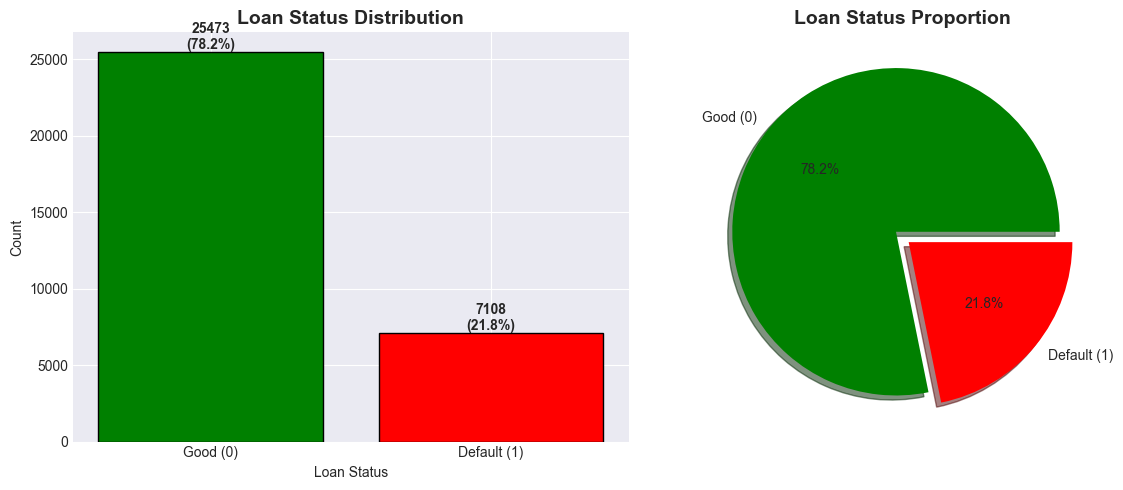

In [12]:
# ============================================
# 1. TARGET VARIABLE DISTRIBUTION
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
colors = ['green', 'red']
counts = df['loan_status'].value_counts()
bars = axes[0].bar(['Good (0)', 'Default (1)'], counts.values, color=colors, edgecolor='black')
axes[0].set_title('Loan Status Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('Count')
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 f'{count}\n({count/len(df)*100:.1f}%)', ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Good (0)', 'Default (1)'], autopct='%1.1f%%', 
            colors=['green', 'red'], explode=(0.05, 0.05), shadow=True)
axes[1].set_title('Loan Status Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

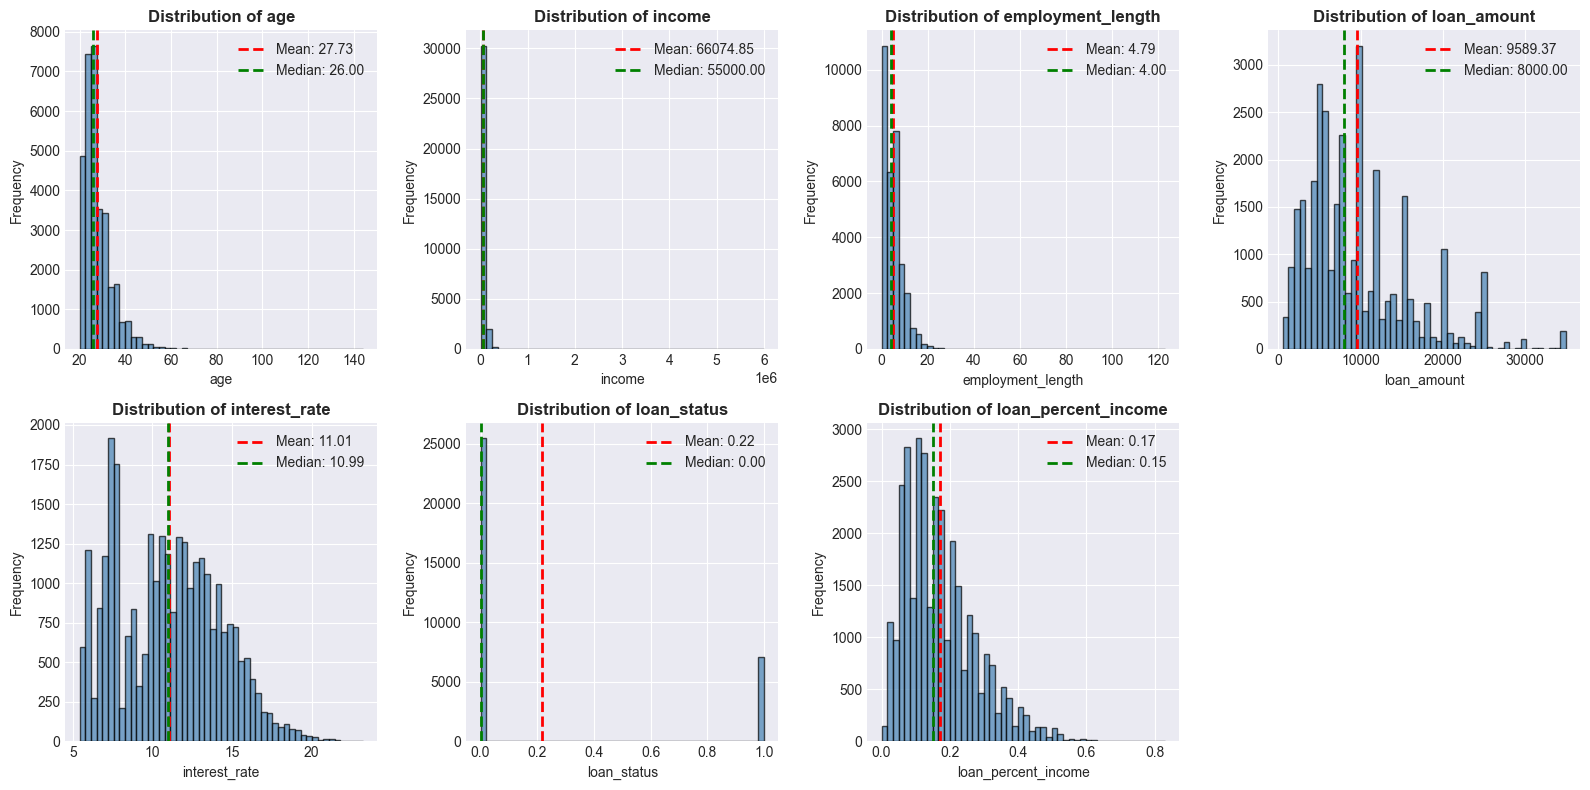

In [17]:
# 2. NUMERICAL FEATURES DISTRIBUTIONS
# ============================================

numeric_cols = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df[col].mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='dashed', linewidth=2, label=f'Median: {df[col].median():.2f}')
    axes[i].legend()

plt.delaxes(axes[7])
plt.tight_layout()
plt.show()

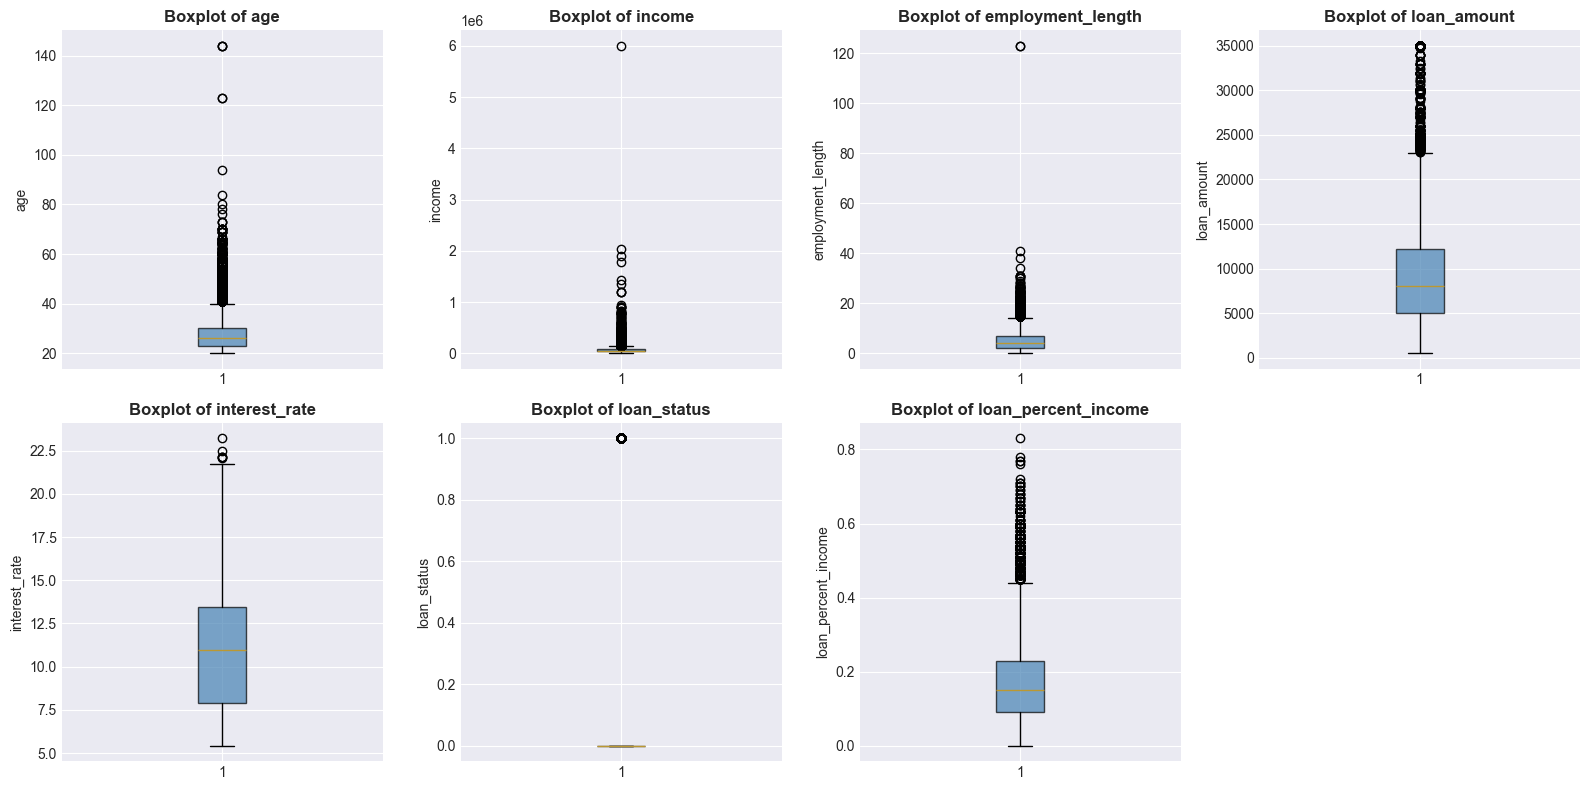

In [18]:
# 3. BOXPLOTS FOR OUTLIER DETECTION
# ============================================

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols[:7]):
    axes[i].boxplot(df[col].dropna(), patch_artist=True, 
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(col)

plt.delaxes(axes[7])
plt.tight_layout()
plt.show()

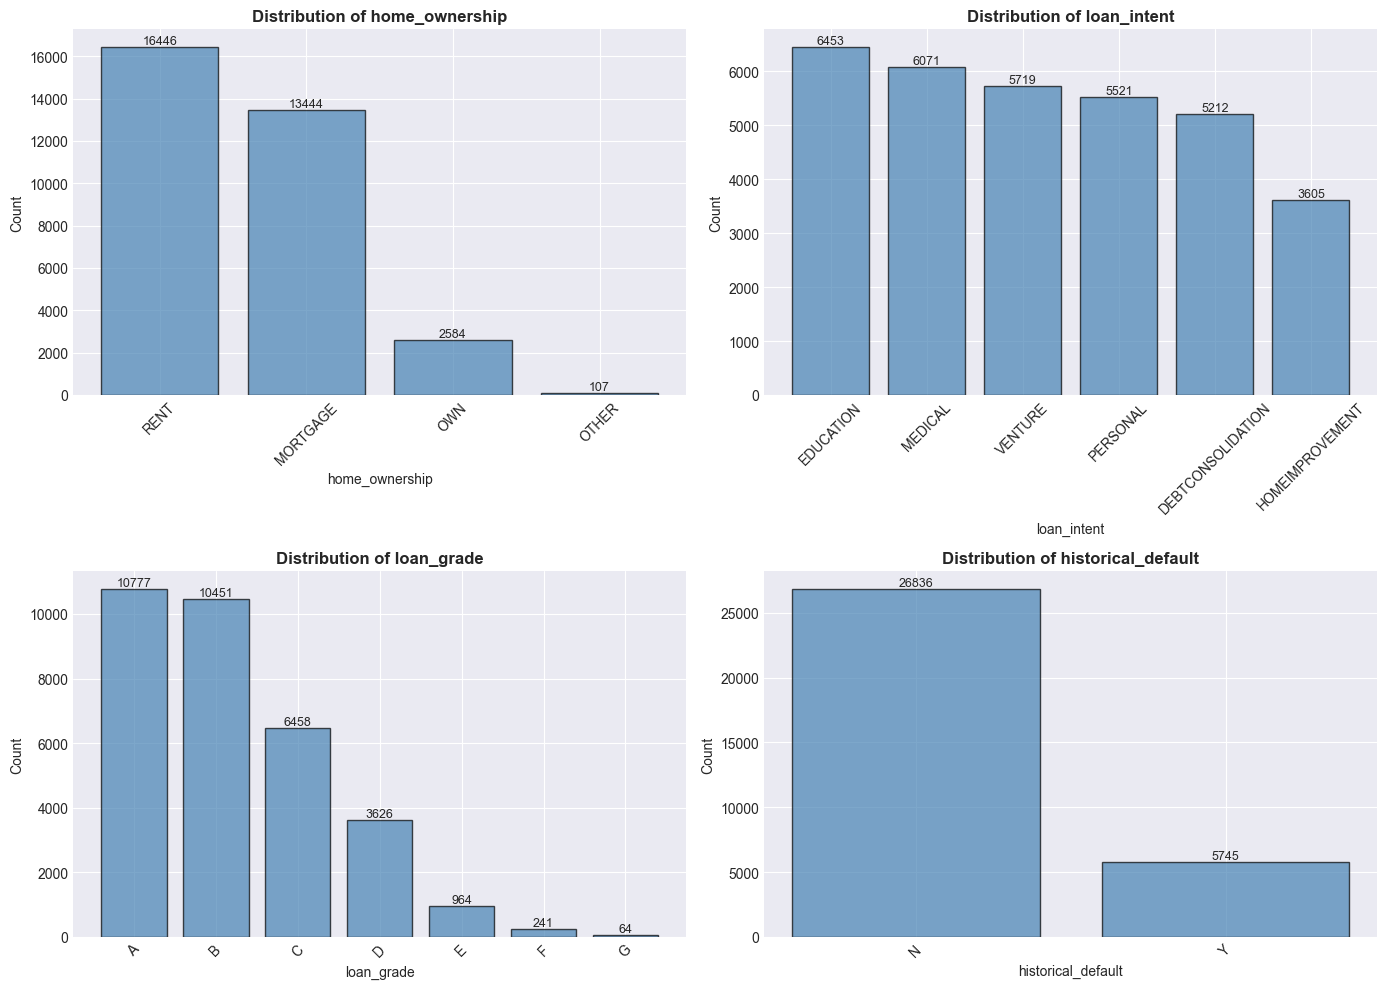

In [20]:
# 4. CATEGORICAL FEATURES DISTRIBUTIONS
# ============================================

categorical_cols = df.select_dtypes(include='string').columns.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    bars = axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
    for bar, count in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                     str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

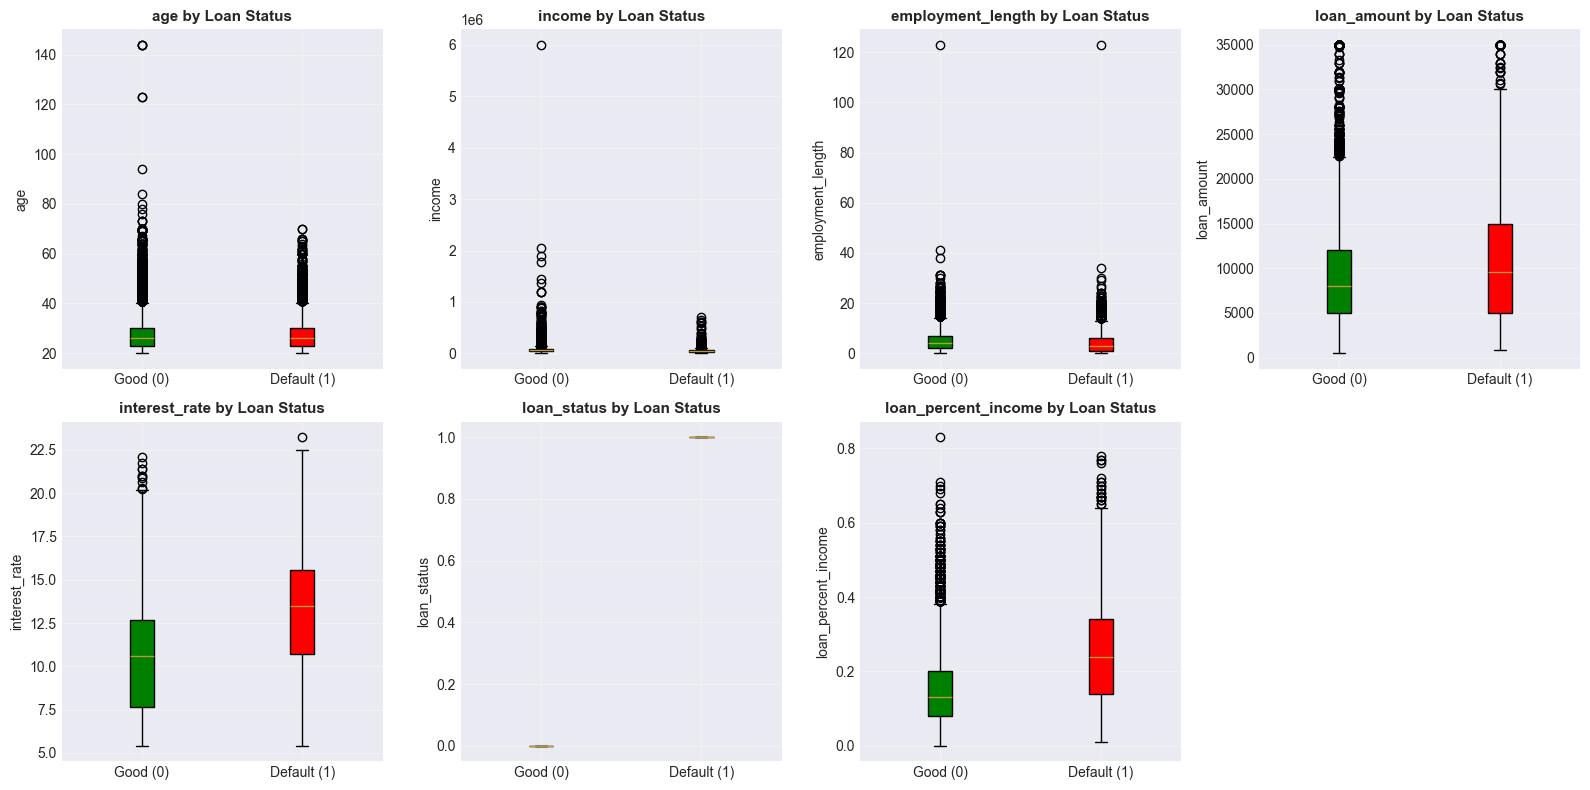

In [21]:
# 6. NUMERICAL FEATURES vs TARGET
# ============================================

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols[:7]):
    data_to_plot = [df[df['loan_status'] == 0][col].dropna(), 
                    df[df['loan_status'] == 1][col].dropna()]
    bp = axes[i].boxplot(data_to_plot, patch_artist=True, labels=['Good (0)', 'Default (1)'])
    bp['boxes'][0].set_facecolor('green')
    bp['boxes'][1].set_facecolor('red')
    axes[i].set_title(f'{col} by Loan Status', fontsize=11, fontweight='bold')
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.3)

plt.delaxes(axes[7])
plt.tight_layout()
plt.show()

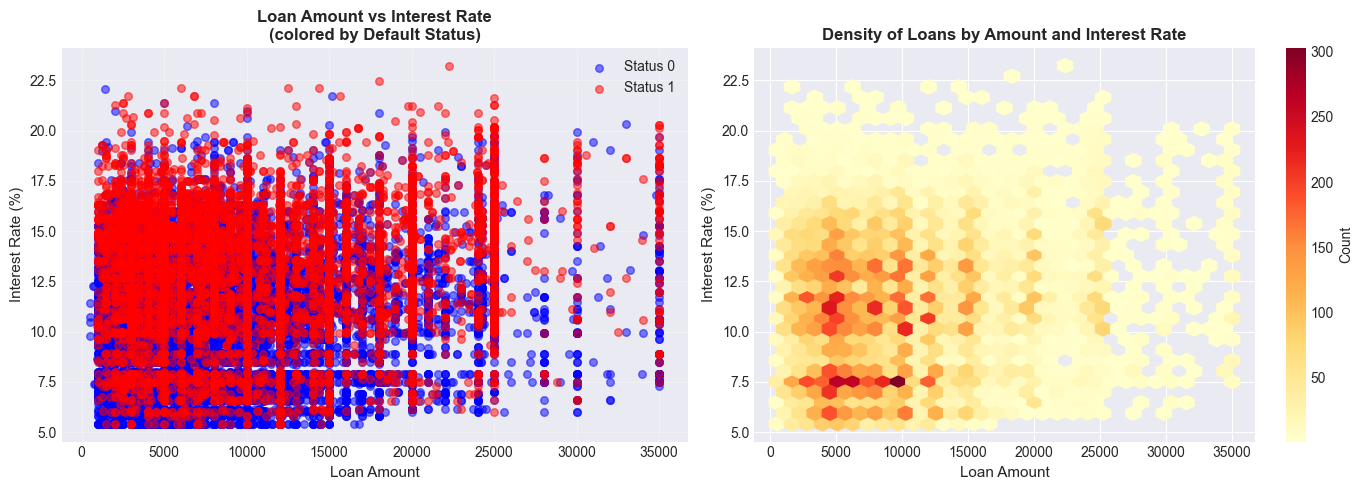

In [23]:
# 7. LOAN AMOUNT vs INTEREST RATE (Colored by Default)
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
colors_map = {0: 'blue', 1: 'red'}
for status in [0, 1]:
    subset = df[df['loan_status'] == status]
    axes[0].scatter(subset['loan_amount'], subset['interest_rate'], 
                    alpha=0.5, label=f'Status {status}', color=colors_map[status], s=30)
axes[0].set_xlabel('Loan Amount', fontsize=11)
axes[0].set_ylabel('Interest Rate (%)', fontsize=11)
axes[0].set_title('Loan Amount vs Interest Rate\n(colored by Default Status)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Hexbin plot for density
hb = axes[1].hexbin(df['loan_amount'], df['interest_rate'], gridsize=30, cmap='YlOrRd', mincnt=1)
axes[1].set_xlabel('Loan Amount', fontsize=11)
axes[1].set_ylabel('Interest Rate (%)', fontsize=11)
axes[1].set_title('Density of Loans by Amount and Interest Rate', fontsize=12, fontweight='bold')
plt.colorbar(hb, ax=axes[1], label='Count')

plt.tight_layout()
plt.show()

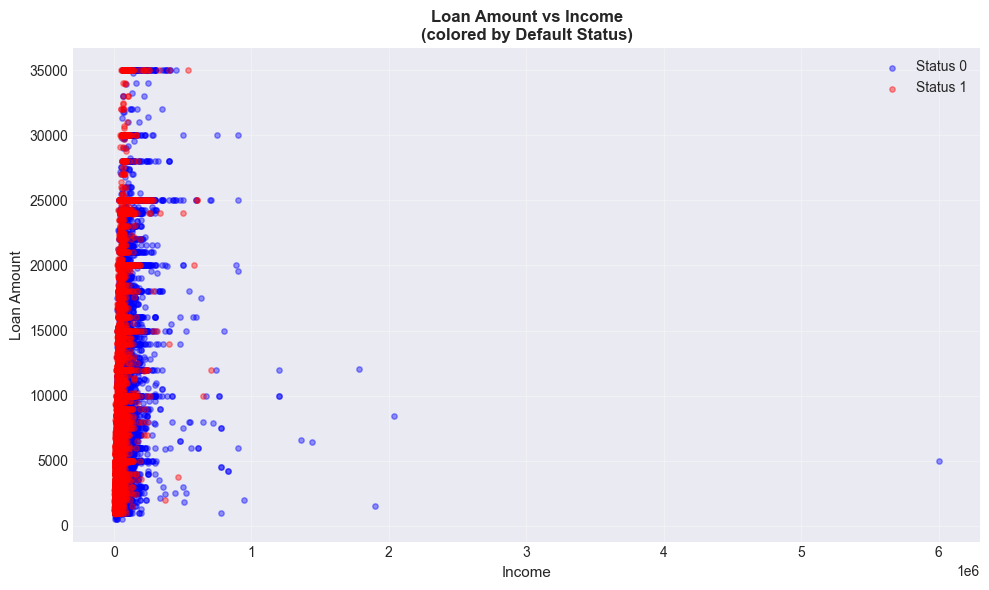

In [31]:
# 8. INCOME vs LOAN AMOUNT (Colored by Default)
# ============================================

plt.figure(figsize=(10, 6))
for status in [0, 1]:
    subset = df[df['loan_status'] == status]
    plt.scatter(subset['income'], subset['loan_amount'], 
                alpha=0.4, label=f'Status {status}', color=colors_map[status], s=15)
plt.xlabel('Income', fontsize=11)
plt.ylabel('Loan Amount', fontsize=11)
plt.title('Loan Amount vs Income\n(colored by Default Status)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

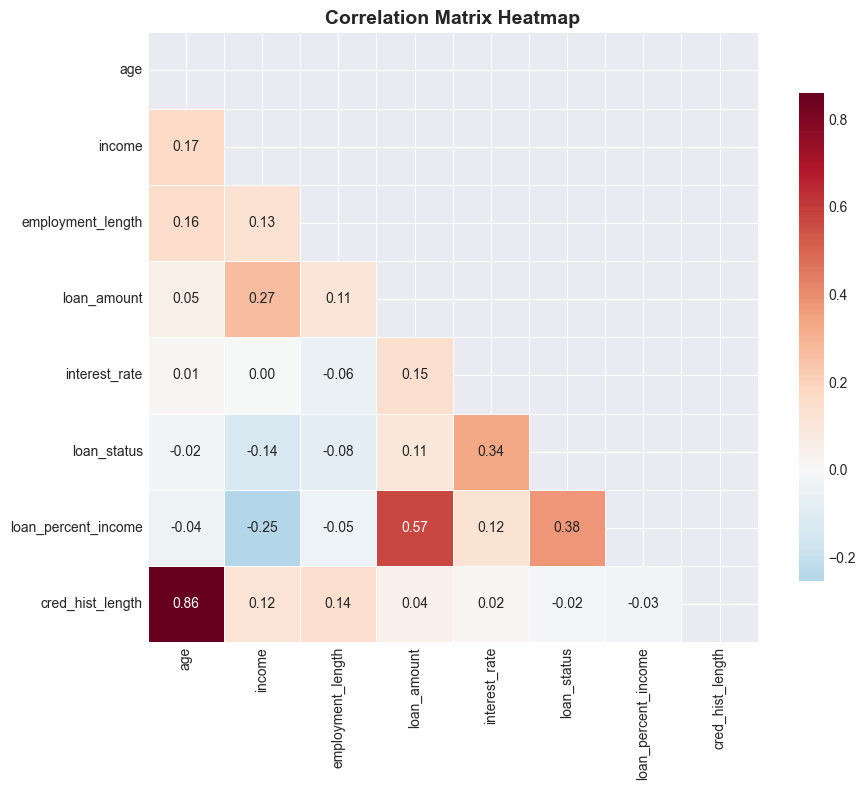

In [44]:
# 9. CORRELATION MATRIX HEATMAP
# ============================================

# Convert categorical to numeric for correlation
df_corr = df.copy()
df_corr['historical_default_num'] = (df_corr['historical_default'] == 'Y').astype(int)

# Select numeric columns
corr_matrix = df_corr[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

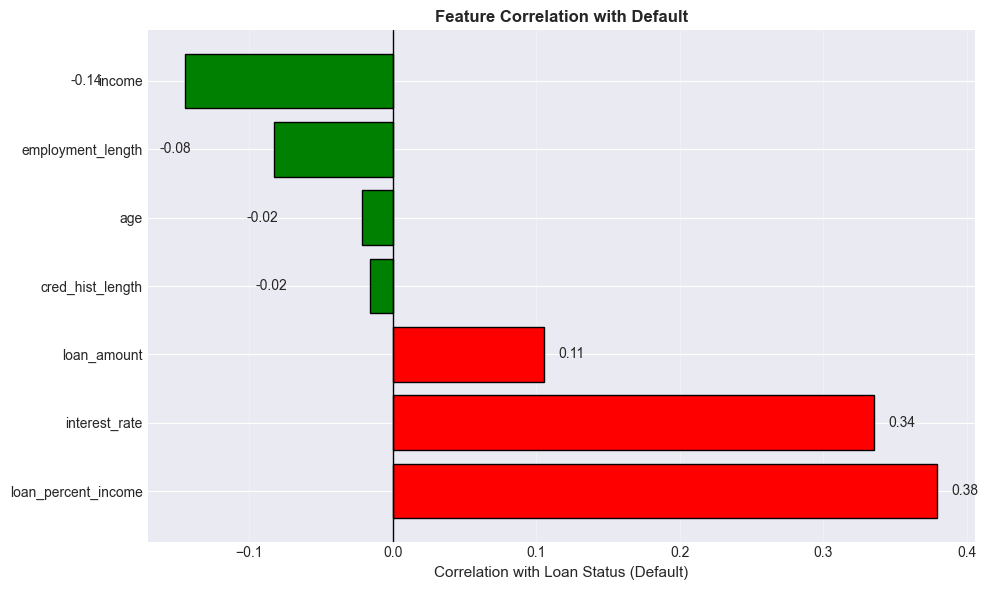

In [42]:
# 10. CORRELATION WITH TARGET (BAR CHART)
# ============================================

corr_with_target = corr_matrix['loan_status'].drop('loan_status').sort_values(ascending=False)
plt.figure(figsize=(10, 6))
colors_corr = ['red' if x > 0 else 'green' for x in corr_with_target.values]
bars = plt.barh(corr_with_target.index, corr_with_target.values, color=colors_corr, edgecolor='black')
plt.xlabel('Correlation with Loan Status (Default)', fontsize=11)
plt.title('Feature Correlation with Default', fontsize=12, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, corr_with_target.values):
    plt.text(bar.get_width() + 0.01 if val > 0 else bar.get_width() - 0.08, 
             bar.get_y() + bar.get_height()/2, f'{val:.2f}', 
             va='center', fontsize=10)
plt.tight_layout()
plt.show()

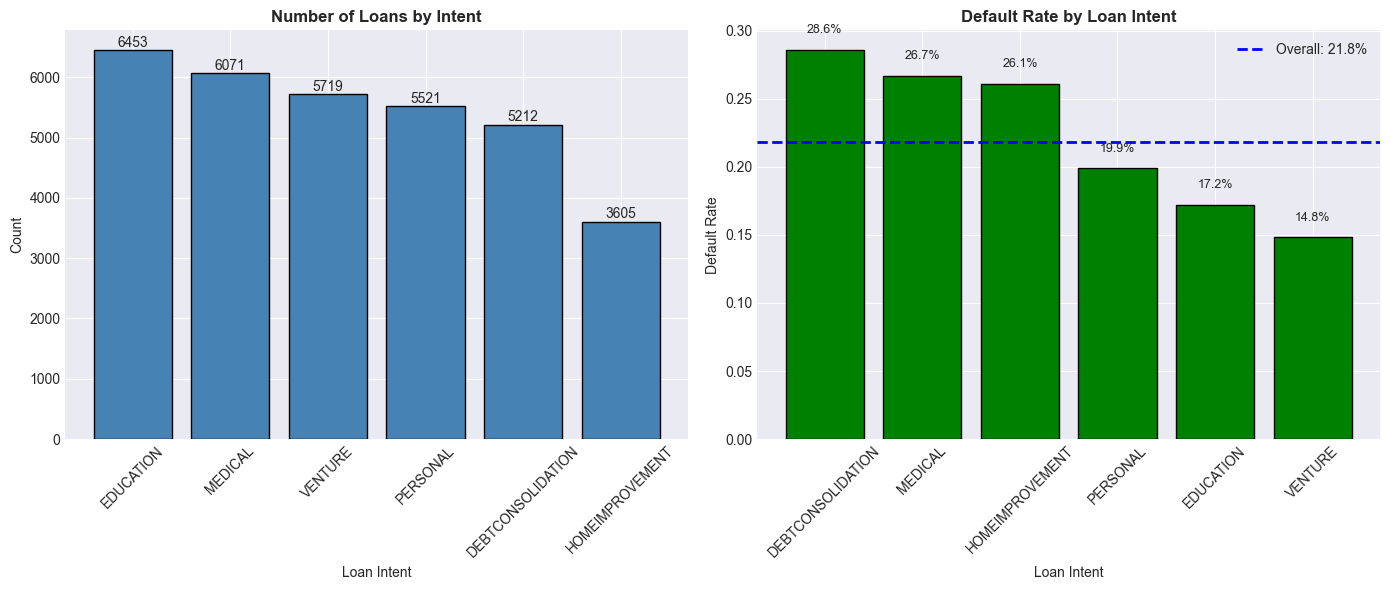

In [47]:
# 11. LOAN INTENT ANALYSIS
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count by loan intent
intent_counts = df['loan_intent'].value_counts()
bars = axes[0].bar(intent_counts.index, intent_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Number of Loans by Intent', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Loan Intent')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for bar, count in zip(bars, intent_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 str(count), ha='center', va='bottom')

# Default rate by loan intent
default_by_intent = df.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=False)
colors = ['red' if x > 0.5 else 'orange' if x > 0.3 else 'green' for x in default_by_intent.values]
bars = axes[1].bar(default_by_intent.index, default_by_intent.values, color=colors, edgecolor='black')
axes[1].axhline(y=df['loan_status'].mean(), color='blue', linestyle='--', 
                linewidth=2, label=f'Overall: {df["loan_status"].mean():.1%}')
axes[1].set_title('Default Rate by Loan Intent', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Loan Intent')
axes[1].set_ylabel('Default Rate')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
for bar, rate in zip(bars, default_by_intent.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{rate:.1%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

<Axes: xlabel='loan_intent'>

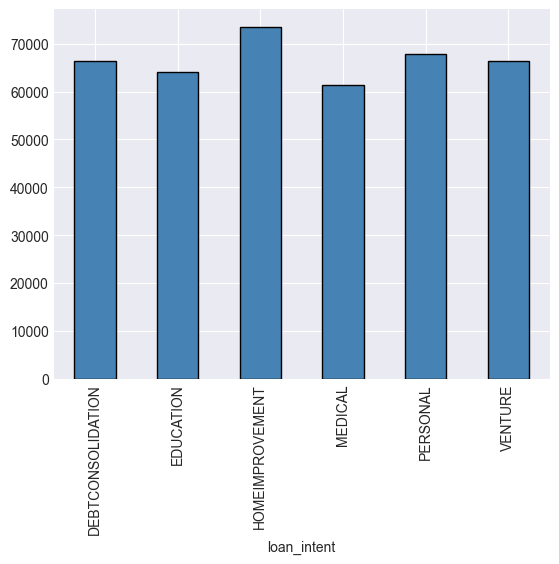

In [53]:
# plotting average according to loan intent
df.groupby('loan_intent')['income'].mean().plot(kind='bar', color='steelblue', edgecolor='black')


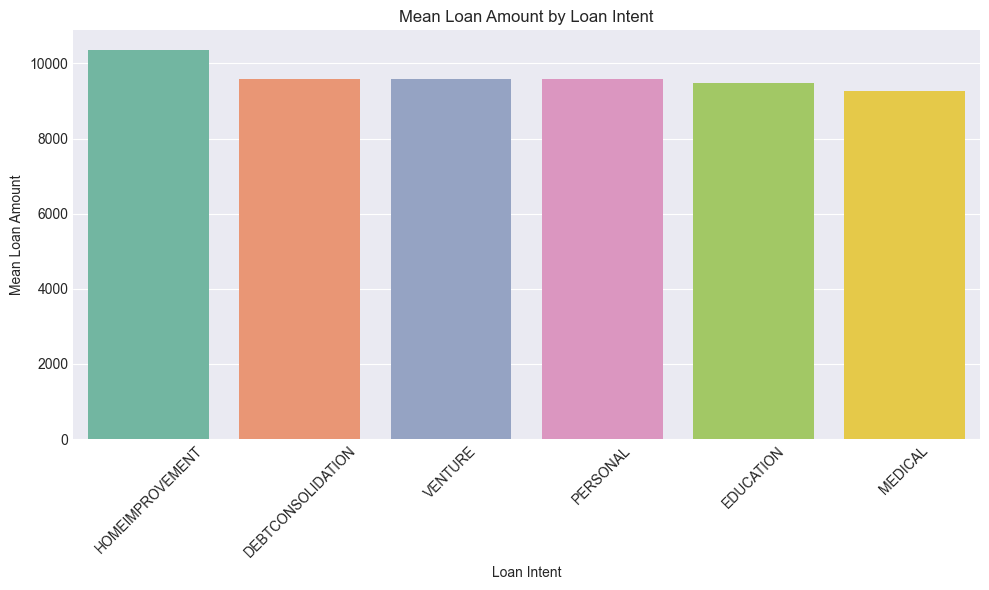

In [56]:
# loan intent vs loan amount
plt.figure(figsize=(10, 6))
means = df.groupby('loan_intent')['loan_amount'].mean().sort_values(ascending=False)
sns.barplot(x=means.index, y=means.values, palette='Set2')
plt.title('Mean Loan Amount by Loan Intent')
plt.xlabel('Loan Intent')
plt.ylabel('Mean Loan Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

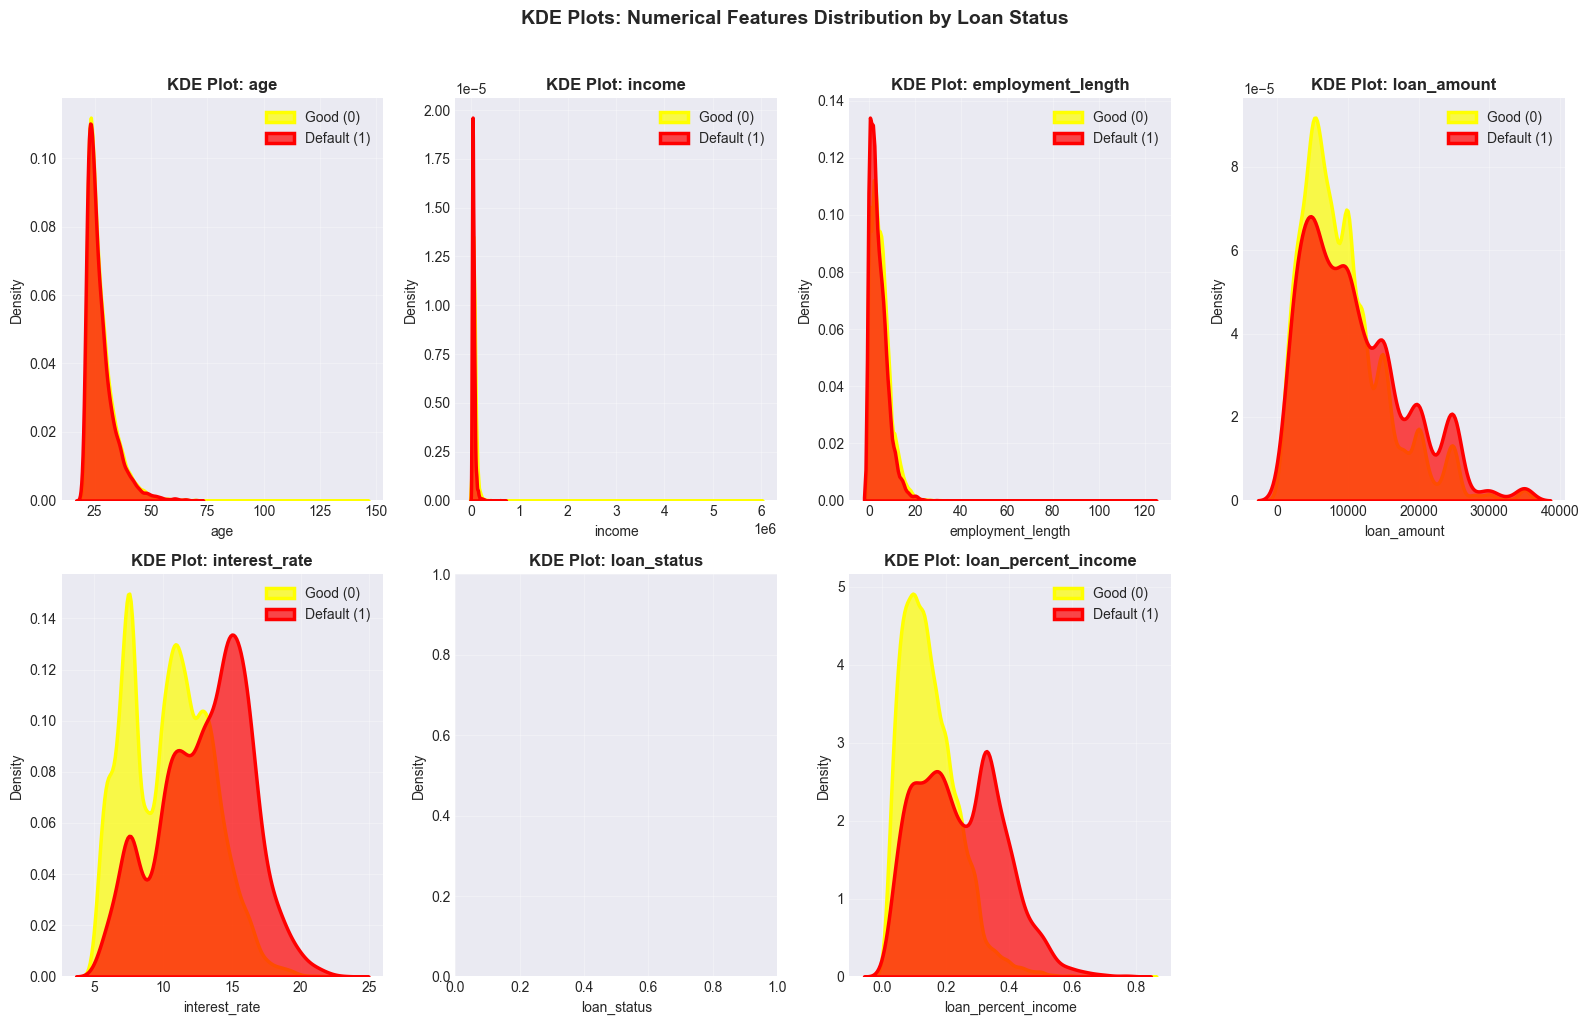

In [63]:
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(numeric_cols):
    # Plot KDE for default=0 (Good) and default=1 (Default)
    for status, color, label in [(0, 'yellow', 'Good (0)'), (1, 'red', 'Default (1)')]:
        data = df[df['loan_status'] == status][feature].dropna()
        if len(data) > 0:
            sns.kdeplot(data=data, label=label, color=color, ax=axes[i], linewidth=2.5, alpha=0.7, fill=True)
    
    axes[i].set_title(f'KDE Plot: {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Density', fontsize=10)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

# Remove empty subplot
plt.delaxes(axes[7])

plt.suptitle('KDE Plots: Numerical Features Distribution by Loan Status', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()